In [53]:
options(warn = -1)
options(repr.plot.width = 15, repr.plot.height = 9)
Sys.setlocale(category = "LC_ALL",locale = "ko_KR.UTF-8") 

[1] "ko_KR.UTF-8/ko_KR.UTF-8/ko_KR.UTF-8/C/ko_KR.UTF-8/C.UTF-8"

### 주성분 분석
: 서로 연관되어 있는 변수들이 관측 되었을 때, 이 변수들이 전체적으로 가지고 있는 정보를 최대한 적은 수의 새로운 변수를 생성하는 방법

In [ ]:
# 설문지를 이용한 주성분 분석
data <- read.table("../Data/pasta.txt")
head(data)

,noodle,dishes,sauce
,<int>,<int>,<int>
pesto_alla_Genovese,2,4,5
Marinara,1,5,1
Puttanesca,5,3,4
Primavera,2,2,3
Vongole,3,5,5
Boscaiola,4,3,2


In [17]:
# 다중 공선성 확인 : 너무 상관이 높아서 마치 쌍둥이 데이터 인 것 찾기
cor(data)

,noodle,dishes,sauce
noodle,1.0000000,0.1905002,0.3600411
dishes,0.1905002,1.0000000,0.3004804
sauce,0.3600411,0.3004804,1.0000000


In [18]:
# 표준화 : 평균을 0으로, 표준편차가 1이 되도록 변경
data1 <- scale(data)
summary(data1)


     noodle            dishes             sauce         
 Min.   :-1.3416   Min.   :-1.36311   Min.   :-1.31112  
 1st Qu.:-0.6708   1st Qu.:-0.51117   1st Qu.:-0.62106  
 Median : 0.0000   Median :-0.08519   Median : 0.06901  
 Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.6708   3rd Qu.: 0.97973   3rd Qu.: 0.58656  
 Max.   : 1.3416   Max.   : 1.19272   Max.   : 1.44914  

In [ ]:
# 정규화 : 컬럼별로 하는 거 | max값으로 나누는 거
# 정규화 : 최대값이 1이 되도록 변경

In [21]:
# 표준화 잘 도ㅔㅆ느지 확인
apply(data1, 2, sd) # 2 : 컬럼별로 나눈거 | 1은 로우

noodle dishes  sauce 
     1      1      1

Standard deviations (1, .., p=3):
[1] 1.2541347 0.9022241 0.7830312

Rotation (n x k) = (3 x 3):
             PC1        PC2        PC3
noodle 0.5715110 -0.6044710  0.5549685
dishes 0.5221161  0.7896069  0.3223595
sauce  0.6330639 -0.1055260 -0.7668731

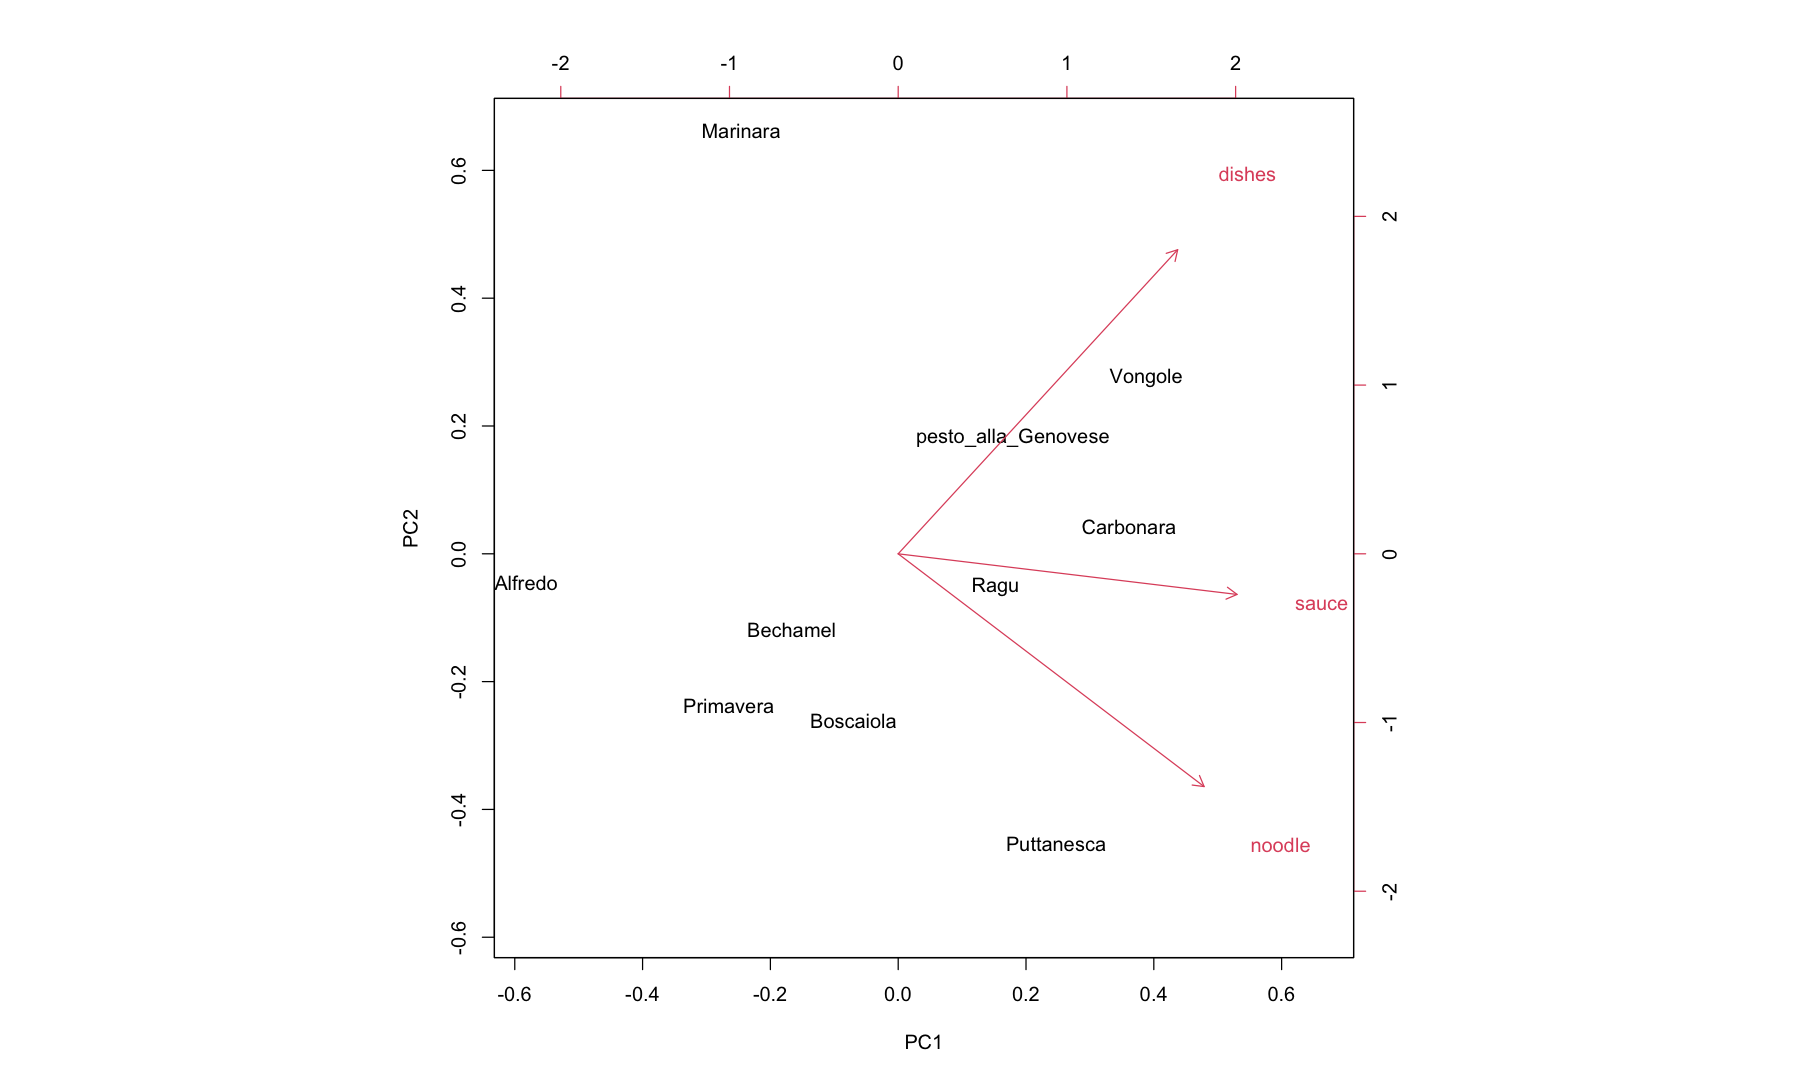

In [23]:
# 주성분 분석
par(bg = "white")
p1 <- prcomp(data, scale = T)
p1
biplot(p1)

In [48]:
# 설문지를 이용한 주성분 분석_ x축을 인덱스로
ramen <- read.table("../Data/라면.txt", header = T)
rownames(ramen) <- ramen$X
ramen <- ramen[,-1]
ramen

,면발,포장재,국물
,<int>,<int>,<int>
신라면,2,4,5
짜파게티,5,2,1
쌀사리곰탕면,3,4,3
무파마,3,3,5
안성탕면,1,2,3
오징어짬뽕,1,3,4
너구리,3,3,4
육계장,2,3,5


In [50]:
ramen <- read.table("../Data/라면.txt", header = T, row.names = 'X')
ramen

,면발,포장재,국물
,<int>,<int>,<int>
신라면,2,4,5
짜파게티,5,2,1
쌀사리곰탕면,3,4,3
무파마,3,3,5
안성탕면,1,2,3
오징어짬뽕,1,3,4
너구리,3,3,4
육계장,2,3,5


Standard deviations (1, .., p=3):
[1] 1.3598983 0.9250247 0.5431446

Rotation (n x k) = (3 x 3):
              PC1          PC2        PC3
면발    0.5246079 -0.703176912  0.4799258
포장재 -0.5207846 -0.711011926 -0.4724885
국물   -0.6734760  0.002066804  0.7392062

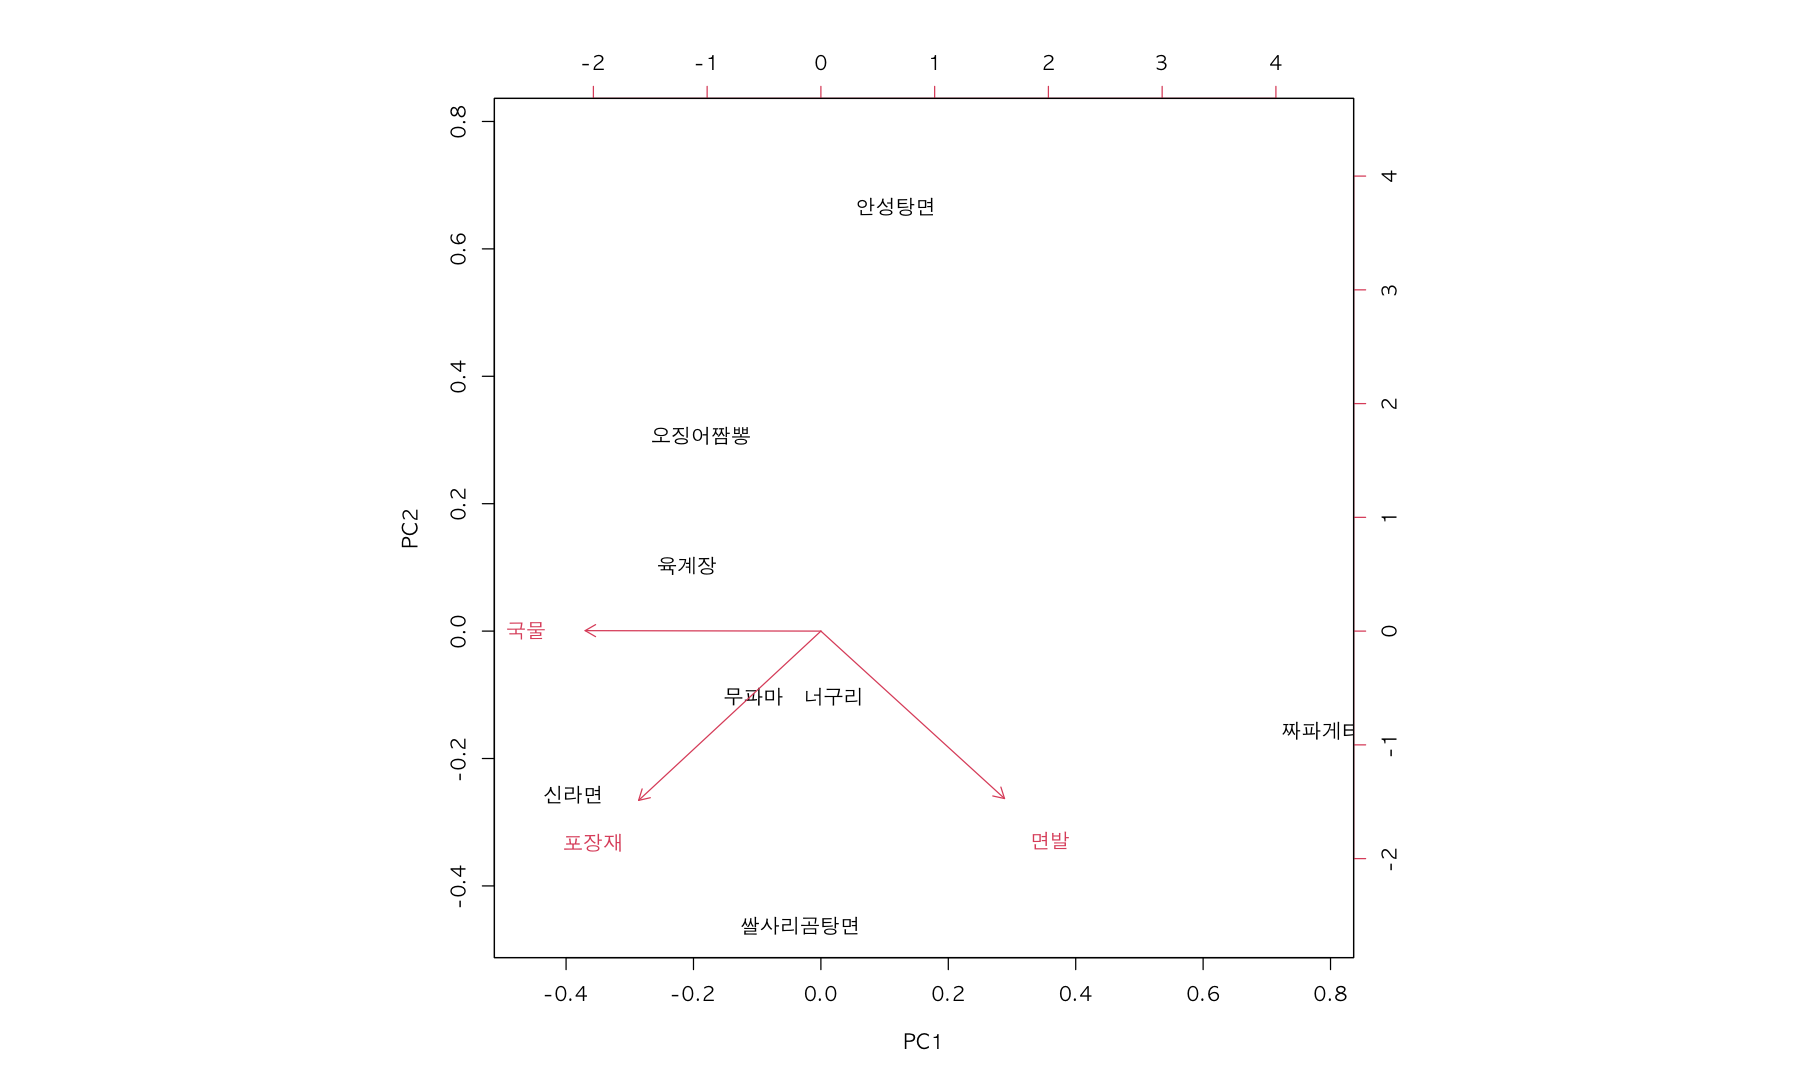

In [57]:
# 주성분 분석 
par(family = "AppleGothic")
par(bg = 'white')
p1 <- prcomp(ramen,scale = T)
p1
biplot(p1)

# 소스 기준 오른쪽으로가면 점수 높은애들 
# 

#### USArrests
: 1973년 미국 50개주에서 각각 10만명당 폭행, 살인, 강간으로 체포된 통계 데이터  
또한 도시지역에 살고 있는 인구의 비율도 있음

In [ ]:
data(USArrests)
head(USArrests)
# Murder : 살인, Assault : 폭행 , 

,Murder,Assault,UrbanPop,Rape
,<dbl>,<int>,<int>,<dbl>
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7


In [60]:
cor(USArrests)

,Murder,Assault,UrbanPop,Rape
Murder,1.00000000,0.8018733,0.06957262,0.5635788
Assault,0.80187331,1.0000000,0.25887170,0.6652412
UrbanPop,0.06957262,0.2588717,1.00000000,0.4113412
Rape,0.56357883,0.6652412,0.41134124,1.0000000


In [61]:
result <- princomp(USArrests, cor = T)
summary(result)

Importance of components:
                          Comp.1    Comp.2    Comp.3     Comp.4
Standard deviation     1.5748783 0.9948694 0.5971291 0.41644938
Proportion of Variance 0.6200604 0.2474413 0.0891408 0.04335752
Cumulative Proportion  0.6200604 0.8675017 0.9566425 1.00000000

In [65]:
result <- princomp(USArrests,cor=T)
summary(result)

Importance of components:
                          Comp.1    Comp.2    Comp.3     Comp.4
Standard deviation     1.5748783 0.9948694 0.5971291 0.41644938
Proportion of Variance 0.6200604 0.2474413 0.0891408 0.04335752
Cumulative Proportion  0.6200604 0.8675017 0.9566425 1.00000000

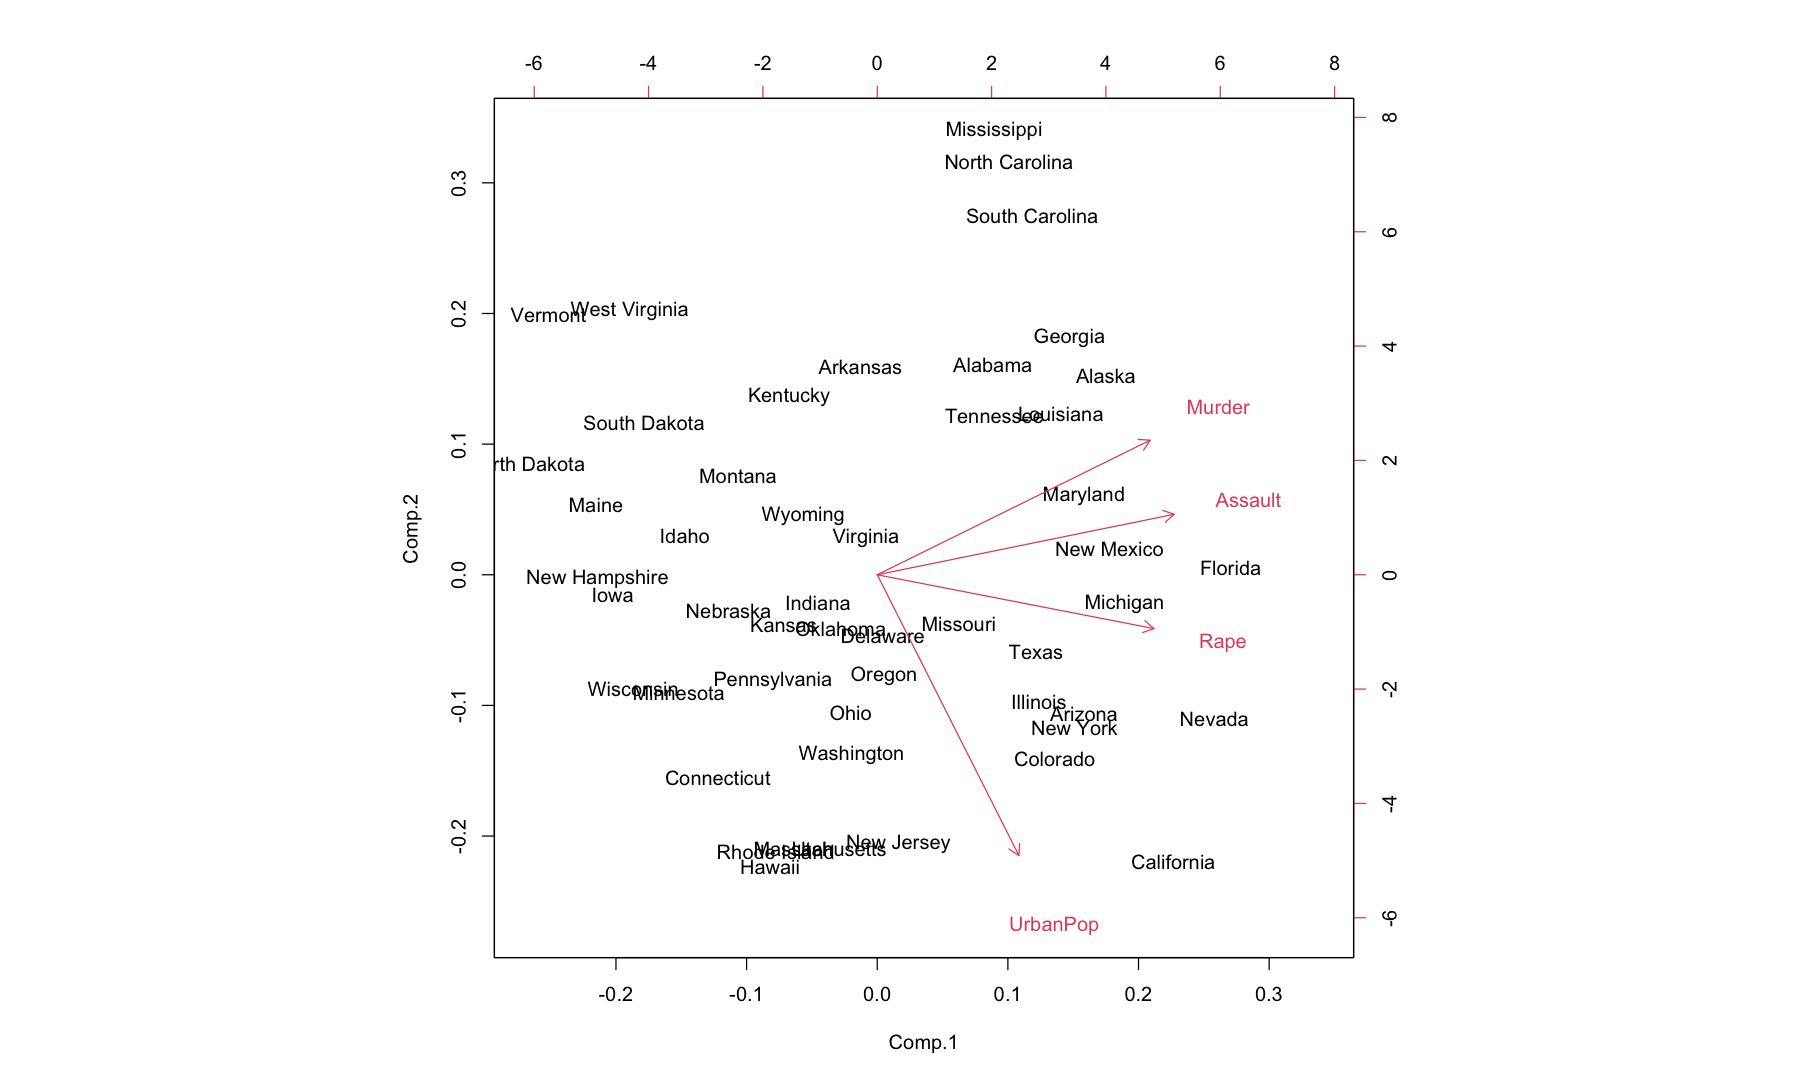

In [67]:
# 주성분 분석 
par(bg = 'white')
biplot(result)

# 소스 기준 오른쪽으로가면 점수 높은애들 
# 

In [69]:
score <- 0.536 * USArrests$Murder +0.583 *USArrests$Assault +0.278 *USArrests$UrbanPop + 0.543* USArrests$Rape 

In [70]:
result <- data.frame(States =row.names(USArrests),Score =score)

head(result)

,States,Score
,<chr>,<dbl>
1,Alabama,172.2988
2,Alaska,196.1965
3,Arizona,214.8166
4,Arkansas,139.9753
5,California,213.0758
6,Colorado,165.8645


In [68]:
# 우선 순위
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [71]:
head(arrange(result,desc(Score)),10)

,States,Score
,<chr>,<dbl>
1,Florida,243.1211
2,North Carolina,224.6913
3,Arizona,214.8166
4,Maryland,214.6782
5,California,213.0758
6,New Mexico,209.1557
7,Nevada,200.9512
8,Alaska,196.1965
9,South Carolina,195.9369


In [ ]:
ㄱ저